# Employee Satisfaction Analysis at Fiktiva

## Portfolio project overview

This notebook presents an end-to-end data analysis project on an employee satisfaction dataset from the fictional company *Fiktiva*. The goal is to demonstrate a clean, reproducible analytical workflow that can also be reused as a template for future projects.

The project is organised in the following stages:

1. understanding the dataset and checking data quality,
2. cleaning and preparing the data,
3. running plausibility checks,
4. exploratory analysis on focused questions,
5. summarising findings, limitations and next steps.

The main business question is:

**Which employee characteristics seem to be related to employee satisfaction, and what data quality issues should be considered before interpreting the results?**

The Python code is kept intentionally simple so the logic is easy to explain and easy to reproduce on another dataset. The written explanations are more detailed than the code because, in a portfolio project, communication matters as much as technical execution.

### About the dataset

The dataset is a synthetic HR file of 700 employees provided during a university data analysis course. The fictional context is fleshed out by a short company newsletter which describes the survey methodology and confirms a few details that appear in the data (for example the company's foundation in 2004 and an employee who received 25 awards). I use this notebook to apply a full analyst workflow — auditing, cleaning, plausibility checks, EDA and reporting — to that dataset.

## 1. Import libraries and load the dataset

I start with the essential libraries only:

- `pandas` for data manipulation,
- `matplotlib.pyplot` for charts,
- `re` for a simple department-ID plausibility check.

I also set a clean default chart style so the visual output stays consistent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# load the dataset
employees = pd.read_csv('datasets/employees_satisfaction.csv', index_col=0)

# first look at the data
employees.head()

,emp_id,age,Dept,education,recruitment_type,job_level,rating,awards,certifications,salary,gender,entry_date,last_raise,satisfied
0,HR8270,28,HR,PG,Referral,5,2,1,0,86750,m,2019-02-01,NaN,1
1,TECH1860,50,Technology,PG,Recruitment Agency,3,5,2,1,42419,Male,2017-01-17,NaN,0
2,TECH6390,43,Technology,UG,Referral,4,1,2,0,65715,f,2012-08-27,NaN,1
3,SAL6191,44,Sales,PG,On-Campus,2,3,0,0,29805,f,2017-07-25,NaN,1
4,HR6734,33,HR,UG,Recruitment Agency,2,1,5,0,29805,m,2019-05-17,NaN,1


## 2. Understand the dataset

Before cleaning or plotting anything, I check what the dataset looks like:

- the number of rows and columns,
- the column names,
- the data types,
- basic summary statistics,
- missing values.

This step answers a key question early: **is the dataset ready for analysis, or are there issues that must be fixed first?**

In [3]:
# number of rows and columns
employees.shape

(700, 14)

In [4]:
# column names
employees.columns

Index(['emp_id', 'age', 'Dept', 'education', 'recruitment_type', 'job_level',
       'rating', 'awards', 'certifications', 'salary', 'gender', 'entry_date',
       'last_raise', 'satisfied'],
      dtype='str')

In [5]:
# data types
employees.dtypes

emp_id                  str
age                   int64
Dept                    str
education               str
recruitment_type        str
job_level             int64
rating                int64
awards                int64
certifications        int64
salary                int64
gender                  str
entry_date              str
last_raise          float64
satisfied             int64
dtype: object

In [6]:
# summary statistics for numerical columns
employees.describe()

,age,job_level,rating,awards,certifications,salary,last_raise,satisfied
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,26.000000,700.00000
mean,39.592857,3.095714,3.082857,4.545714,0.507143,51434.781429,0.049231,0.68000
std,8.800683,1.423584,1.414818,2.982432,0.594400,23783.358796,0.029519,0.46681
min,22.000000,1.000000,1.000000,0.000000,0.000000,24076.000000,0.010000,0.00000
25%,33.000000,2.000000,2.000000,2.000000,0.000000,29805.000000,0.020000,0.00000
50%,39.000000,3.000000,3.000000,5.000000,0.000000,42419.000000,0.050000,1.00000
75%,47.000000,4.000000,4.000000,7.000000,1.000000,65715.000000,0.077500,1.00000
max,56.000000,5.000000,5.000000,25.000000,9.000000,86750.000000,0.100000,1.00000


In [7]:
# count missing values in each column
employees.isna().sum()

emp_id                0
age                   0
Dept                  0
education             0
recruitment_type      0
job_level             0
rating                0
awards                0
certifications        0
salary                0
gender                6
entry_date            0
last_raise          674
satisfied             0
dtype: int64

### Initial observations

From the first inspection, the dataset already provides useful business information: age, department, education, job level, salary, performance rating, and satisfaction.

This first check also reveals early data quality issues:

1. The column `last_raise` contains 674 missing values, which is more than 80% of the rows. This column does not have enough coverage for reliable analysis and will be dropped.
2. The column `gender` contains 6 missing values out of 700 rows. Small, but it must be handled explicitly.
3. The column `entry_date` is stored as a string. It must be converted to datetime before any time-based analysis.
4. The columns `awards` and `certifications` may contain extreme values, as their maximum is far above three standard deviations from the mean. These will be examined in the plausibility checks.

## 3. Clean and prepare the data

The purpose of cleaning is not just to make the code run. It is to make the analysis more reliable and the outputs easier to interpret.

The main cleaning steps are:

1. rename unclear columns (for example `Dept` becomes `department`),
2. convert `entry_date` to datetime,
3. standardise categorical values that mean the same thing,
4. handle missing values,
5. drop columns that cannot be used reliably,
6. create derived columns such as `entry_year`.

In [8]:
# rename Dept to department for readability
employees = employees.rename(columns={'Dept': 'department'})

employees.columns

Index(['emp_id', 'age', 'department', 'education', 'recruitment_type',
       'job_level', 'rating', 'awards', 'certifications', 'salary', 'gender',
       'entry_date', 'last_raise', 'satisfied'],
      dtype='str')

In [9]:
# convert entry_date to datetime
employees['entry_date'] = pd.to_datetime(employees['entry_date'])

employees['entry_date'].head()

0   2019-02-01
1   2017-01-17
2   2012-08-27
3   2017-07-25
4   2019-05-17
Name: entry_date, dtype: datetime64[us]

In [10]:
# inspect categories in every text column (except the ID, which is just an identifier)
for col in employees.columns:
    if pd.api.types.is_string_dtype(employees[col]) and col != 'emp_id':
        print(f"The column {col} contains the following categories:")
        print(employees[col].unique().tolist())
        print('-' * 50)

The column department contains the following categories:
['HR', 'Technology', 'Sales', 'Purchasing', 'Marketing']
--------------------------------------------------
The column education contains the following categories:
['PG', 'UG']
--------------------------------------------------
The column recruitment_type contains the following categories:
['Referral', 'Recruitment Agency', 'On-Campus', 'Walk-in']
--------------------------------------------------
The column gender contains the following categories:
['m', 'Male', 'f', 'Female', nan]
--------------------------------------------------


The category check reveals two issues:

- In `gender`, women appear as both `'f'` and `'Female'`, and men as both `'m'` and `'Male'`. These will be unified.
- In `education`, the codes `UG` and `PG` refer to Undergraduate and Postgraduate. These will be replaced with the full names for readability.

In [11]:
# unify gender categories
employees['gender'] = employees['gender'].replace({'m': 'Male', 'f': 'Female'})

employees['gender'].value_counts(dropna=False)

gender
Male      364
Female    330
NaN         6
Name: count, dtype: int64

In [12]:
# standardise education labels
employees['education'] = employees['education'].replace({'UG': 'Undergraduate', 'PG': 'Postgraduate'})

employees['education'].unique().tolist()

['Postgraduate', 'Undergraduate']

In [13]:
# replace the 6 missing gender values with 'Unknown' so they remain visible in the analysis
employees['gender'] = employees['gender'].fillna('Unknown')

employees['gender'].value_counts()

gender
Male       364
Female     330
Unknown      6
Name: count, dtype: int64

In [14]:
# drop last_raise because more than 80% of the values are missing
employees = employees.drop(columns=['last_raise'])

employees.columns

Index(['emp_id', 'age', 'department', 'education', 'recruitment_type',
       'job_level', 'rating', 'awards', 'certifications', 'salary', 'gender',
       'entry_date', 'satisfied'],
      dtype='str')

In [15]:
# create a new column for the year of entry, useful for cohort analysis
employees['entry_year'] = employees['entry_date'].dt.year

employees[['entry_date', 'entry_year']].head()

,entry_date,entry_year
0,2019-02-01,2019
1,2017-01-17,2017
2,2012-08-27,2012
3,2017-07-25,2017
4,2019-05-17,2019


### Why these cleaning steps matter

- Renaming `Dept` to `department` makes the column name clearer and consistent.
- Standardising `gender` and `education` avoids having multiple labels for the same group, which would split counts and bias group averages.
- Converting `entry_date` to datetime makes any time-based analysis possible.
- Dropping `last_raise` removes a column that would be statistically unreliable.
- Filling missing genders with `'Unknown'` keeps those rows in the dataset and makes the gap visible, rather than silently dropping them.
- Creating `entry_year` provides a simple way to compare satisfaction across employee cohorts.

## 4. Plausibility checks

It is also important to check whether the data makes sense after handling missing values and labels

I perform three simple plausibility checks:

1. whether employee IDs match their department,
2. whether employees were old enough when they joined,
3. whether some columns contain suspicious values.

In [16]:
# check whether the employee ID prefix matches the department
# the prefix is the non-numeric part of the ID (HR8270 -> HR)
prefix_to_department = {
    'HR': 'HR',
    'TECH': 'Technology',
    'SAL': 'Sales',
    'MKT': 'Marketing',
    'FIN': 'Finance',
    'PUR': 'Purchasing',
}

mismatches = []
for i in range(len(employees)):
    emp_id = employees.iloc[i]['emp_id']
    department = employees.iloc[i]['department']
    prefix = re.sub(r'\d+', '', emp_id)
    expected = prefix_to_department.get(prefix)
    if expected != department:
        mismatches.append(i)

print(f"Number of ID/department mismatches: {len(mismatches)} out of {len(employees)} rows")

Number of ID/department mismatches: 0 out of 700 rows


In [17]:
# calculate how old each employee was when they joined the company
# we compare entry_year with the implied year of birth (2026 - current_age)
today_year = 2026
employees['entry_age'] = employees['entry_year'] - (today_year - employees['age'])

employees[['age', 'entry_year', 'entry_age']].head()

,age,entry_year,entry_age
0,28,2019,21
1,50,2017,41
2,43,2012,29
3,44,2017,35
4,33,2019,26


In [18]:
# count employees who appear to have joined before age 16
under_16 = employees[employees['entry_age'] < 16]
print(f"Number of employees with entry_age < 16: {len(under_16)} ({len(under_16)/len(employees)*100:.1f}% of the dataset)")

under_16[['emp_id', 'age', 'entry_date', 'entry_age']].head(10)

Number of employees with entry_age < 16: 66 (9.4% of the dataset)


,emp_id,age,entry_date,entry_age
10,MKT2685,31,2009-01-24,14
12,TECH7949,28,2013-04-24,15
19,SAL4385,25,2012-02-15,11
24,SAL3047,31,2006-09-05,11
37,SAL6393,33,2006-10-21,13
40,SAL8513,34,2005-10-15,13
44,MKT6486,29,2009-01-18,12
49,HR2585,33,2008-12-10,15
64,MKT7439,33,2008-09-19,15
71,HR5859,24,2014-08-24,12


In [19]:
# check the awards column
employees['awards'].describe()

count    700.000000
mean       4.545714
std        2.982432
min        0.000000
25%        2.000000
50%        5.000000
75%        7.000000
max       25.000000
Name: awards, dtype: float64

In [20]:
# look at the full distribution of awards to spot outliers
employees['awards'].value_counts().sort_index()

awards
0     72
1     63
2     71
3     74
4     67
5     76
6     71
7     62
8     65
9     78
25     1
Name: count, dtype: int64

In [21]:
# check certifications
employees['certifications'].value_counts(dropna=False)

certifications
0    353
1    346
9      1
Name: count, dtype: int64

### Interpretation of the plausibility checks

- **ID consistency:** every employee ID prefix matches the department field. This is a strong sign that the dataset is internally consistent and that the ID-to-department mapping can be trusted.
- **Entry age:** around 9% of employees have an implied entry age below 16, which would be implausible in a real company. Since this is a synthetic dataset, this is most likely an artefact of how the data was generated rather than a real issue. In a real project, these rows would be flagged and discussed with whoever produced the data before being used or excluded.
- **Awards:** the distribution is fairly uniform between 0 and 9, with one extreme value of 25 awards. The company newsletter independently confirms that one employee (Sofia Price) actually received her 25th award, so this is an extreme but legitimate value rather than a data error. The analysis keeps the row, but I would still flag it when reporting averages.
- **Certifications:** the column should only contain 0 (not certified) or 1 (certified), but one record has a value of 9. This is likely a data entry error and that row should be flagged or excluded before using this column in any analysis.

This section shows that data analysis is not just about making charts — it is also about questioning the quality and provenance of the information behind those charts.

## 5. Exploratory analysis

After the data audit and cleaning, I move to exploratory data analysis (EDA).

The aim is not to prove causality, but to look for patterns that might be useful for HR or management. I focus on a small number of clear questions:

1. What is the overall satisfaction level?
2. Does satisfaction vary by department?
3. Does satisfaction vary by job level?
4. Does satisfaction vary by performance rating?
5. Does satisfaction vary by recruitment type?
6. Is salary different between satisfied and unsatisfied employees?
7. Does satisfaction vary across entry-year cohorts?

A small number of focused questions usually produces a stronger portfolio than many disconnected charts.

In [22]:
# overall satisfaction distribution
satisfaction_overall = employees['satisfied'].value_counts(normalize=True) * 100
satisfaction_overall.round(1)

satisfied
1    68.0
0    32.0
Name: proportion, dtype: float64

In [23]:
# satisfaction by department, as a percentage
satisfaction_by_department = (
    employees.groupby('department')['satisfied'].mean() * 100
).sort_values(ascending=False).round(1)

satisfaction_by_department

department
Sales         77.2
Technology    68.8
HR            67.6
Purchasing    66.7
Marketing     61.2
Name: satisfied, dtype: float64

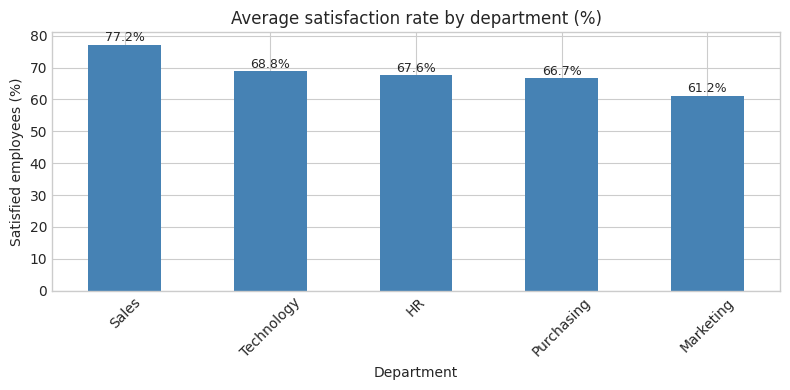

In [24]:
# bar chart with value labels
ax = satisfaction_by_department.plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.title('Average satisfaction rate by department (%)')
plt.xlabel('Department')
plt.ylabel('Satisfied employees (%)')
plt.xticks(rotation=45)
for i, v in enumerate(satisfaction_by_department):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# satisfaction by job level
satisfaction_by_level = (employees.groupby('job_level')['satisfied'].mean() * 100).round(1)
satisfaction_by_level

job_level
1    70.3
2    72.7
3    69.0
4    63.2
5    65.8
Name: satisfied, dtype: float64

In [26]:
# satisfaction by performance rating
satisfaction_by_rating = (employees.groupby('rating')['satisfied'].mean() * 100).round(1)
satisfaction_by_rating

rating
1    68.2
2    69.6
3    67.7
4    63.3
5    71.6
Name: satisfied, dtype: float64

In [27]:
# satisfaction by recruitment type
satisfaction_by_recruitment = (
    employees.groupby('recruitment_type')['satisfied'].mean() * 100
).sort_values(ascending=False).round(1)

satisfaction_by_recruitment

recruitment_type
Walk-in               75.8
On-Campus             70.4
Recruitment Agency    66.4
Referral              63.0
Name: satisfied, dtype: float64

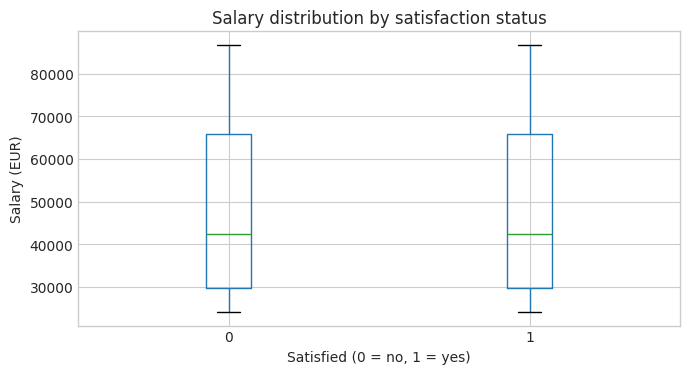

,mean,median
satisfied,,
0,53480.0,42419.0
1,50472.0,42419.0


In [28]:
# salary distribution split by satisfaction status
employees.boxplot(column='salary', by='satisfied', figsize=(7, 4))
plt.title('Salary distribution by satisfaction status')
plt.suptitle('')  # remove default pandas suptitle
plt.xlabel('Satisfied (0 = no, 1 = yes)')
plt.ylabel('Salary (EUR)')
plt.tight_layout()
plt.show()

employees.groupby('satisfied')['salary'].agg(['mean', 'median']).round(0)

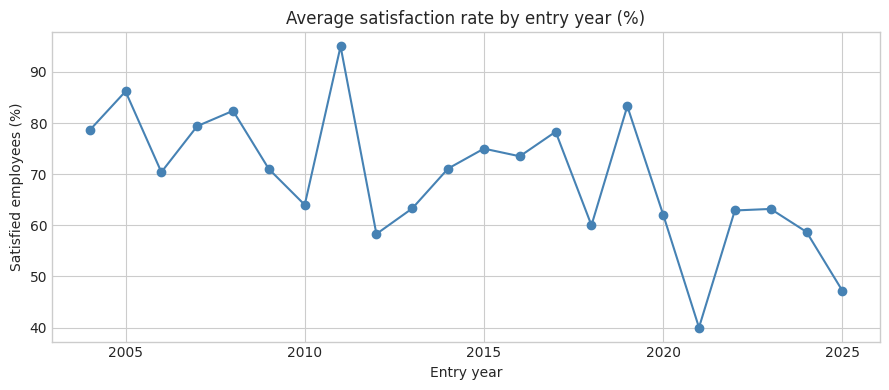

entry_year
2004    78.6
2005    86.2
2006    70.4
2007    79.4
2008    82.4
2009    71.0
2010    64.0
2011    95.0
2012    58.3
2013    63.3
2014    71.1
2015    75.0
2016    73.5
2017    78.3
2018    60.0
2019    83.3
2020    62.1
2021    40.0
2022    62.9
2023    63.2
2024    58.7
2025    47.2
Name: satisfied, dtype: float64

In [29]:
# satisfaction by entry year
satisfaction_by_year = (employees.groupby('entry_year')['satisfied'].mean() * 100).round(1)

satisfaction_by_year.plot(kind='line', marker='o', figsize=(9, 4), color='steelblue')
plt.title('Average satisfaction rate by entry year (%)')
plt.xlabel('Entry year')
plt.ylabel('Satisfied employees (%)')
plt.tight_layout()
plt.show()

satisfaction_by_year

## 6. Key findings

The exploratory analysis produced the following concrete results.

**Overall satisfaction.** 68% of employees report being satisfied, against 32% unsatisfied. This is a healthy baseline but leaves a meaningful minority worth investigating.

**Department.** Sales has the highest satisfaction rate at 77.2%, followed by Technology (68.8%), HR (67.6%) and Purchasing (66.7%). Marketing is clearly the lowest at 61.2%, a 16-point gap with Sales. This is the strongest signal in the dataset and would be the first thing to raise with HR.

**Job level.** Satisfaction is fairly stable across levels (between 63% and 73%), with no strong pattern. Level 4 employees are the least satisfied (63.2%), which could be a mid-career frustration point worth a closer look.

**Performance rating.** Surprisingly, satisfaction does *not* increase smoothly with performance rating. Top-rated employees (rating 5) report 71.6% satisfaction, but rating 1 employees are also at 68.2%. This suggests that satisfaction in this dataset is not strongly driven by individual performance.

**Recruitment type.** Walk-in hires are the most satisfied (75.8%) and Referrals the least (63.0%), a 13-point gap. This is counter-intuitive, since referrals are often assumed to fit company culture better, and would be worth verifying.

**Salary.** Median salary is essentially identical between satisfied and unsatisfied employees (around 42,400 EUR). Mean salary is even slightly higher among the unsatisfied (53,500 EUR vs 50,500 EUR). In this dataset, pay does not appear to be the main driver of satisfaction.

**Entry-year cohorts.** Satisfaction is declining among recent hires: employees who joined in 2021 report only 40% satisfaction, and 2025 hires are at 47%. Cohorts from 2004 to 2019 are mostly above 70%. The decline among recent hires is the second-strongest signal in the dataset and would also be worth raising with HR.

## 7. Limitations

A strong analytical project should state its limitations clearly.

- The dataset is synthetic and contains 700 fictional employees. Findings cannot be generalised to a real organisation and the project is meant to demonstrate workflow, not to produce business decisions.
- `satisfied` is a binary field, which simplifies a more nuanced reality.
- Around 9% of records show an implausible entry age (below 16), likely an artefact of synthetic data generation. These rows were kept but flagged.
- The analysis is descriptive and exploratory. It identifies patterns but does not prove causality. For example, the lower satisfaction of Marketing employees might be driven by an unobserved variable such as workload or management style.
- Group sizes vary, so percentages for small entry-year cohorts (for example 2011, with very few records) are unstable and should be interpreted with caution.

## 8. What I would do next

With more time or more data, the natural next steps would be:

- run a logistic regression with `satisfied` as the target to estimate the relative weight of each driver (department, recruitment type, entry year, etc.),
- collect additional variables such as workload, manager and tenure to test richer hypotheses,
- compare the declining satisfaction trend among recent hires with company-level events (reorganisations, policy changes...) to look for plausible causes,
- segment the Marketing department in more detail to understand the satisfaction gap.

## 9. Conclusion

This project demonstrates a simple but complete data analyst workflow:

1. understand the dataset,
2. assess data quality,
3. clean the important fields,
4. run plausibility checks,
5. explore the data with focused visualisations,
6. communicate findings and limitations.

The exact columns will change from project to project, but the analytical structure remains the same. The code is kept simple on purpose, so it stays readable and reusable.